# Week 3｜文本表示基础

## 从词频统计到语义向量空间

> **本周问题**：计算机不能直接理解文字。我们如何把一段文本变成可以比较、检索和输入模型的数字？

本 Notebook 将完成：`预处理 → TF-IDF → Word2Vec → 相似度 → t-SNE 可视化`。

---
## 0｜环境检查与 Notebook 魔法命令

本周新增两个库：`jieba` 用于中文分词，`gensim` 用于 Word2Vec。若下方环境检查显示缺失，请运行下一格中取消注释的 `%pip` 命令；安装后通过 **Kernel → Restart Kernel** 重启内核。

In [2]:
# 如提示缺少 jieba 或 gensim，删除下一行开头的 # 后运行一次
# %pip install jieba gensim

%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
import re
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

for package in ['jieba', 'gensim', 'sklearn']:
    status = '已安装 ✓' if importlib.util.find_spec(package) else '未安装 ✗'
    print(f'{package}: {status}')

sns.set_theme(style='whitegrid', palette='Set2')
np.random.seed(42)

     ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
     ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
     ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
     --------------------------------------- 0.0/19.2 MB 262.6 kB/s eta 0:01:14
     --------------------------------------- 0.0/19.2 MB 262.6 kB/s eta 0:01:14
     --------------------------------------- 0.0/19.2 MB 217.9 kB/s eta 0:01:29
     --------------------------------------- 0.1/19.2 MB 374.1 kB/s eta 0:00:52
     --------------------------------------- 0.1/19.2 MB 423.5 kB/s eta 0:00:46
     --------------------------------------- 0.2/19.2 MB 525.1 kB/s eta 0:00:37
      -------------------------------------- 0.3/19.2 MB 684.6 kB/s eta 0:00:28
      -------------------------------------- 0.4/19.2 MB 890.4 kB/s eta 0:00:22
     - -------------------------------------- 0.5/19.2 MB 1.2 MB/s eta 0:00:16
     - -------------------------------------- 0.7/19.2 MB 1.5 MB/


[notice] A new release of pip is available: 23.2.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1｜文本表示路线图

```text
原始文本 → 清洗 / 分词 → 词或子词序列 → 数字表示 → 下游任务
                                      ├─ TF-IDF：统计重要性
                                      └─ Word2Vec：学习语义相近
```

- **TF-IDF**：关心词在当前文档中是否重要；它不知道“漏洞”和“缺陷”语义接近。
- **Word2Vec**：从上下文中学习词向量；经常在相似语境出现的词，向量可能更接近。
- **注意**：词向量是否可靠，根本取决于训练语料的规模、质量和领域匹配程度。

---
## 2｜中文预处理：清洗、分词、停用词

中文句子没有天然空格，因此一般需要分词。下面的函数依次完成：

1. 使用正则表达式去除特殊符号；
2. 使用 `jieba.lcut` 将句子拆成词；
3. 删除非常常见但区分度很低的停用词；
4. 保留长度大于 1 的词。

In [3]:
import jieba

stop_words = {'的', '了', '和', '是', '在', '与', '及', '对', '一个', '我们', '进行'}

def preprocess_zh(text):
    """输入原始中文字符串，输出清洗后的词列表。"""
    clean_text = re.sub(r'[^\u4e00-\u9fa5a-zA-Z0-9]', ' ', text)
    tokens = jieba.lcut(clean_text)
    tokens = [token for token in tokens if token not in stop_words and len(token) > 1]
    return tokens

sample_text = '安全运营人员需要分析漏洞公告、异常登录日志和钓鱼邮件！'
print('原始文本：', sample_text)
print('预处理后：', preprocess_zh(sample_text))

Building prefix dict from the default dictionary ...


原始文本： 安全运营人员需要分析漏洞公告、异常登录日志和钓鱼邮件！


Dumping model to file cache C:\Users\lfr\AppData\Local\Temp\jieba.cache
Loading model cost 0.613 seconds.
Prefix dict has been built successfully.


预处理后： ['安全', '运营', '人员', '需要', '分析', '漏洞', '公告', '异常', '登录', '日志', '钓鱼', '邮件']


### 练习 1｜观察预处理的影响

修改下一格的文本，输入一条你感兴趣的网络安全句子。观察哪些词被保留、哪些符号被移除；不要把分词结果当作绝对正确，它仍可能切错专业术语。

In [4]:
my_text = 'TODO：在这里写一条与网络安全或大模型相关的中文句子。'
print(preprocess_zh(my_text))

['TODO', '这里', '一条', '网络安全', '模型', '相关', '中文', '句子']


---
## 3｜TF-IDF：从词频到关键词

对词 $t$ 和文档 $d$：

$$TF(t,d)=\frac{\text{词 }t\text{ 在 }d\text{ 中出现次数}}{\text{文档总词数}}$$

$$IDF(t)=\log\frac{N}{DF(t)}$$

$$TFIDF(t,d)=TF(t,d)\times IDF(t)$$

直觉：在当前文档常出现、但在其他文档不常出现的词，更可能是关键词。

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

documents = [
    '漏洞公告描述认证绕过风险和修复建议',
    '安全运营团队分析异常登录日志并处置告警',
    '检索增强生成系统从知识库检索漏洞公告',
    '钓鱼邮件检测需要分析链接文本和发件人信息',
    '大语言模型可以基于检索证据生成安全分析报告',
]

# tokenizer=preprocess_zh：让 TF-IDF 使用我们上面定义的中文分词函数
vectorizer = TfidfVectorizer(tokenizer=preprocess_zh, token_pattern=None)

%time tfidf_matrix = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names_out()

print('TF-IDF 矩阵形状:', tfidf_matrix.shape, '= (文档数, 词表大小)')
print('词表：', feature_names.tolist())

CPU times: total: 31.2 ms
Wall time: 31.5 ms
TF-IDF 矩阵形状: (5, 36) = (文档数, 词表大小)
词表： ['信息', '修复', '公告', '分析', '发件人', '可以', '告警', '团队', '基于', '增强', '处置', '安全', '建议', '异常', '报告', '描述', '文本', '日志', '检测', '检索', '模型', '漏洞', '生成', '登录', '知识库', '系统', '绕过', '认证', '证据', '语言', '运营', '邮件', '钓鱼', '链接', '需要', '风险']


### 练习 2｜查看每篇文档的 Top 关键词

下一格按 TF-IDF 分数从高到低输出每篇文档的 5 个关键词。观察“安全”“漏洞”这类高频词是否一定是区分度最高的词。

In [6]:
def top_tfidf_terms(row, feature_names, top_n=5):
    row_array = row.toarray().ravel()
    top_indices = row_array.argsort()[-top_n:][::-1]
    return [(feature_names[i], round(row_array[i], 3)) for i in top_indices if row_array[i] > 0]

for index, document in enumerate(documents):
    print(f'文档 {index + 1}：{document}')
    print('关键词：', top_tfidf_terms(tfidf_matrix[index], feature_names))
    print('—' * 50)

文档 1：漏洞公告描述认证绕过风险和修复建议
关键词： [('风险', np.float64(0.37)), ('建议', np.float64(0.37)), ('认证', np.float64(0.37)), ('绕过', np.float64(0.37)), ('修复', np.float64(0.37))]
——————————————————————————————————————————————————
文档 2：安全运营团队分析异常登录日志并处置告警
关键词： [('异常', np.float64(0.351)), ('日志', np.float64(0.351)), ('登录', np.float64(0.351)), ('运营', np.float64(0.351)), ('团队', np.float64(0.351))]
——————————————————————————————————————————————————
文档 3：检索增强生成系统从知识库检索漏洞公告
关键词： [('检索', np.float64(0.587)), ('增强', np.float64(0.364)), ('系统', np.float64(0.364)), ('知识库', np.float64(0.364)), ('漏洞', np.float64(0.293))]
——————————————————————————————————————————————————
文档 4：钓鱼邮件检测需要分析链接文本和发件人信息
关键词： [('需要', np.float64(0.344)), ('链接', np.float64(0.344)), ('钓鱼', np.float64(0.344)), ('邮件', np.float64(0.344)), ('发件人', np.float64(0.344))]
——————————————————————————————————————————————————
文档 5：大语言模型可以基于检索证据生成安全分析报告
关键词： [('报告', np.float64(0.345)), ('模型', np.float64(0.345)), ('语言', np.float64(0.345)), ('证据', np.float64(0.345

### 文档相似度：TF-IDF 的一个 RAG 入口

余弦相似度比较两个向量的方向。这里使用 TF-IDF 向量计算文档间相似度；这与 RAG 中的“向量检索”思路相似，但 RAG 通常使用更强的语义嵌入模型。

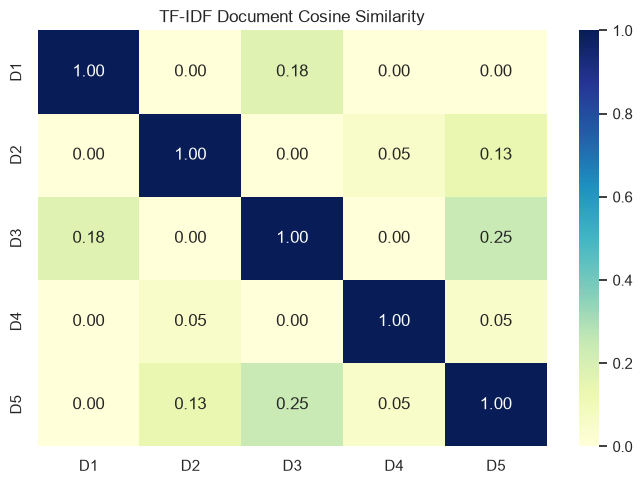

In [7]:
similarity_matrix = cosine_similarity(tfidf_matrix)

plt.figure(figsize=(7, 5))
sns.heatmap(similarity_matrix, annot=True, fmt='.2f', cmap='YlGnBu',
            xticklabels=[f'D{i+1}' for i in range(len(documents))],
            yticklabels=[f'D{i+1}' for i in range(len(documents))])
plt.title('TF-IDF Document Cosine Similarity')
plt.tight_layout()
plt.show()

# TODO：哪两篇文档最相似？它们共享了哪些关键词？

---
## 4｜Word2Vec：从共现上下文学习语义向量

Word2Vec 不是手工统计词频，而是通过大量句子的上下文训练词向量。

- **CBOW (`sg=0`)**：用上下文预测中心词，通常更快；
- **Skip-gram (`sg=1`)**：用中心词预测上下文，常被认为对低频词更友好。

本 Notebook 使用一个很小的教学语料，因此相似词结果只用于理解流程，**不能当作可靠的真实语义结论**。

In [9]:
from gensim.models import Word2Vec

raw_sentences = [
    '漏洞公告提供修复建议和风险等级',
    '安全团队分析漏洞风险并发布修复通知',
    '认证绕过漏洞可能导致未授权访问',
    '异常登录告警需要安全运营人员处置',
    '安全运营平台聚合日志告警和威胁情报',
    '钓鱼邮件包含可疑链接和伪造发件人',
    '邮件检测模型识别钓鱼链接和恶意附件',
    '检索增强生成从知识库检索相关证据',
    '大语言模型根据检索证据生成安全报告',
    '向量检索可以查找相似的漏洞公告',
]

# 重复语料仅为让极小教学语料有更多训练步；真实研究必须使用真实且足够大的语料
tokenized_sentences = [preprocess_zh(sentence) for sentence in raw_sentences] * 80

%time
w2v_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=50,      # 每个词由 50 个数字表示；真实模型往往更高维
    window=3,            # 观察中心词左右 3 个词的上下文
    min_count=1,
    workers=1,           # 固定为 1，保证教学结果更可复现
    sg=1,                # 1 表示 Skip-gram
    epochs=100,
    seed=42,
)

print('词表大小：', len(w2v_model.wv))
print('词向量形状：', w2v_model.wv['漏洞'].shape)

CPU times: total: 0 ns
Wall time: 0 ns
词表大小： 55
词向量形状： (50,)


## 5｜查询相似词与词向量相似度

`most_similar` 返回余弦相似度最高的词。结果只表示该小语料中的上下文共现关系，不等于严格的专业知识或因果关系。

In [10]:
for word in ['漏洞', '安全', '检索']:
    print(f'\n与「{word}」最相近的词：')
    print(w2v_model.wv.most_similar(word, topn=5))

print('漏洞 与 修复 的相似度：', round(w2v_model.wv.similarity('漏洞', '修复'), 4))
print('漏洞 与 钓鱼 的相似度：', round(w2v_model.wv.similarity('漏洞', '钓鱼'), 4))

# TODO：把 sg=1 改为 sg=0，重新训练后比较两个词的相似词变化。


与「漏洞」最相近的词：
[('风险', 0.5264000296592712), ('访问', 0.5207287073135376), ('等级', 0.5121317505836487), ('通知', 0.48672476410865784), ('修复', 0.48491787910461426)]

与「安全」最相近的词：
[('语言', 0.5240437984466553), ('发布', 0.5043720006942749), ('告警', 0.5022775530815125), ('通知', 0.48844560980796814), ('情报', 0.4571039080619812)]

与「检索」最相近的词：
[('证据', 0.6612272262573242), ('生成', 0.649420440196991), ('相似', 0.6206486821174622), ('相关', 0.6062381267547607), ('增强', 0.5972113609313965)]
漏洞 与 修复 的相似度： 0.4849
漏洞 与 钓鱼 的相似度： 0.0651


---
## 6｜t-SNE：把高维词向量投影到二维

Word2Vec 的词向量有 50 维，人眼难以直接观察。t-SNE 把它压到二维以便画图。

**正确解读：**图中相近的词可作为探索线索；不同次运行、不同参数或不同语料都可能改变图形，不能仅凭二维图得出强结论。

C:\Users\lfr\AppData\Local\Temp\ipykernel_37472\2114063633.py:21: UserWarning: Glyph 28431 (\N{CJK UNIFIED IDEOGRAPH-6F0F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lfr\AppData\Local\Temp\ipykernel_37472\2114063633.py:21: UserWarning: Glyph 27934 (\N{CJK UNIFIED IDEOGRAPH-6D1E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lfr\AppData\Local\Temp\ipykernel_37472\2114063633.py:21: UserWarning: Glyph 20462 (\N{CJK UNIFIED IDEOGRAPH-4FEE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lfr\AppData\Local\Temp\ipykernel_37472\2114063633.py:21: UserWarning: Glyph 22797 (\N{CJK UNIFIED IDEOGRAPH-590D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lfr\AppData\Local\Temp\ipykernel_37472\2114063633.py:21: UserWarning: Glyph 39118 (\N{CJK UNIFIED IDEOGRAPH-98CE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lfr\AppData\Local\Temp\ipykernel_37472\2114063633.py:21: UserWarning: Glyph 38505 (\N{CJK UNIFIED IDEOGRAPH-9669}) missing fro

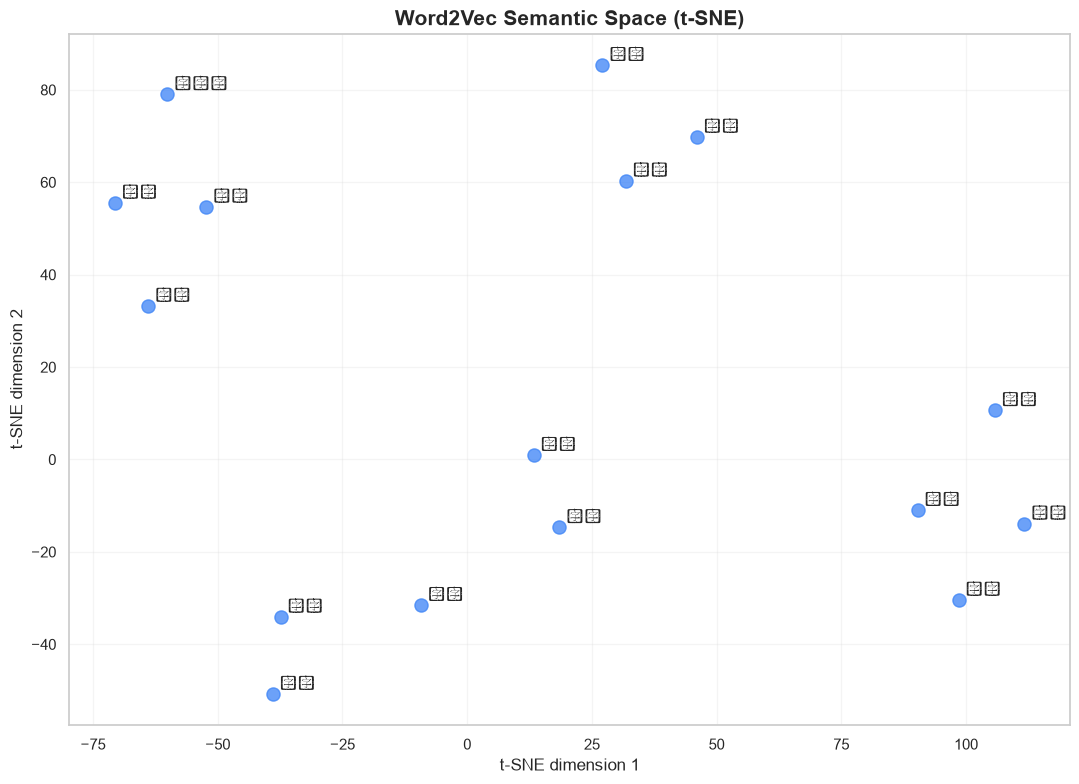

已保存：week3_word2vec_tsne.png


In [11]:
from sklearn.manifold import TSNE

words = ['漏洞', '修复', '风险', '认证', '访问', '告警', '日志', '运营',
         '钓鱼', '邮件', '链接', '检测', '检索', '知识库', '证据', '生成']
words = [word for word in words if word in w2v_model.wv]
vectors = np.array([w2v_model.wv[word] for word in words])  # (词数, 50)

# perplexity 必须小于样本数；本例词数少，因此取 5
tsne = TSNE(n_components=2, random_state=42, perplexity=5, max_iter=1000, init='pca')
positions = tsne.fit_transform(vectors)  # (词数, 2)

plt.figure(figsize=(11, 8))
plt.scatter(positions[:, 0], positions[:, 1], s=90, alpha=0.75, color='#3b82f6')
for index, word in enumerate(words):
    plt.annotate(word, (positions[index, 0], positions[index, 1]),
                 xytext=(5, 5), textcoords='offset points', fontsize=11)
plt.title('Word2Vec Semantic Space (t-SNE)', fontsize=15, fontweight='bold')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('week3_word2vec_tsne.png', dpi=220, bbox_inches='tight')
plt.show()
print('已保存：week3_word2vec_tsne.png')